In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("lahore_flats_feature_engineered.csv")

In [3]:
df.columns

Index(['name', 'marla', 'area_sqft', 'floor_number', 'total_floors',
       'built_year', 'address', 'description', 'floor', 'floors_in_building',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [4]:
df = df.drop(columns=["name", "description"])

In [5]:
df = df.drop(columns=["address"])

In [6]:
df[['floor_number','total_floors','floor','floors_in_building']]

,floor_number,total_floors,floor,floors_in_building
0,8.0,11.0,8.0,11.0
1,NaN,13.0,NaN,13.0
2,6.0,11.0,6.0,11.0
3,NaN,8.0,NaN,8.0
4,1.0,9.0,1.0,9.0
...,...,...,...,...
2494,2.0,7.0,2.0,7.0
2495,1.0,NaN,1.0,NaN
2496,NaN,7.0,NaN,7.0
2497,NaN,NaN,NaN,NaN


In [7]:
df = df.drop(columns=["floor", "floors_in_building"])


In [8]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms'],
      dtype='object')

In [9]:
df["area_sqft"] = pd.to_numeric(df["area_sqft"], errors="coerce")
df["price_per_sqft"] = df["price"] / df["area_sqft"]


In [10]:
df.columns

Index(['marla', 'area_sqft', 'floor_number', 'total_floors', 'built_year',
       'bedrooms', 'bathrooms', 'kitchens', 'servant_quarters', 'store_rooms',
       'price', 'society', 'luxury_score', 'drawing_room', 'dining_room',
       'lounge_or_sitting_room', 'laundry_room', 'study_room', 'prayer_room',
       'powder_room', 'gym', 'steam_room', 'other_rooms', 'price_per_sqft'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   marla                   2499 non-null   float64
 1   area_sqft               2499 non-null   float64
 2   floor_number            1095 non-null   float64
 3   total_floors            1352 non-null   float64
 4   built_year              1800 non-null   float64
 5   bedrooms                2145 non-null   float64
 6   bathrooms               2146 non-null   float64
 7   kitchens                2074 non-null   float64
 8   servant_quarters        1657 non-null   float64
 9   store_rooms             1723 non-null   float64
 10  price                   2499 non-null   int64  
 11  society                 2499 non-null   object 
 12  luxury_score            2499 non-null   int64  
 13  drawing_room            2499 non-null   int64  
 14  dining_room             2499 non-null   

In [12]:
df.duplicated().sum()

np.int64(36)

In [13]:
df = df.drop_duplicates()

In [14]:
df.shape

(2463, 24)

In [15]:
df.head()

,marla,area_sqft,floor_number,total_floors,built_year,bedrooms,bathrooms,kitchens,servant_quarters,store_rooms,...,dining_room,lounge_or_sitting_room,laundry_room,study_room,prayer_room,powder_room,gym,steam_room,other_rooms,price_per_sqft
0,1.3,353.925,8.0,11.0,NaN,1.0,1.0,1.0,1.0,1.0,...,1,1,1,0,0,0,0,0,0,15257.469803
1,1.8,490.050,NaN,13.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,1,0,0,0,0,0,0,0,4401.591674
2,2.2,598.950,6.0,11.0,NaN,1.0,1.0,1.0,NaN,NaN,...,0,0,0,0,0,0,0,0,0,13356.707572
3,2.2,598.950,NaN,8.0,2023.0,NaN,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,3339.176893
4,2.2,598.950,1.0,9.0,2023.0,1.0,1.0,1.0,1.0,1.0,...,1,1,1,1,1,1,1,1,1,4173.971116


## Univarient Analysis
- Col dist
- outliers
- missing val

## society                 

In [16]:
df['society'].value_counts().shape

(87,)

In [17]:
df['society'].value_counts()

society
Askari 11         499
Gulberg           293
Askari 10         288
DHA Defence       250
Raiwind Road      232
                 ... 
Sant Nagar          1
Super Town          1
Saadi Park          1
EME Society         1
Cavalry Ground      1
Name: count, Length: 87, dtype: int64

In [18]:
df[df["society"] != "Askari 11"]["society"].value_counts(normalize=True).cumsum().head(75)


society
Gulberg                                0.149185
Askari 10                              0.295825
DHA Defence                            0.423116
Raiwind Road                           0.541242
Gulberg 3                              0.624745
                                         ...   
Mustafa Town                           0.992363
Abdul Sattar Edhi Road                 0.992872
Bahria Education & Medical City        0.993381
Shabbir Town - Executive Apartments    0.993890
Davis Road                             0.994399
Name: proportion, Length: 75, dtype: float64

In [19]:
society_counts = df["society"].value_counts()

frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}

frequency_bins


{'Very High (>100)': np.int64(6),
 'High (50-100)': np.int64(4),
 'Average (10-49)': np.int64(12),
 'Low (2-9)': np.int64(39),
 'Very Low (1)': np.int64(26)}

<Axes: xlabel='society'>

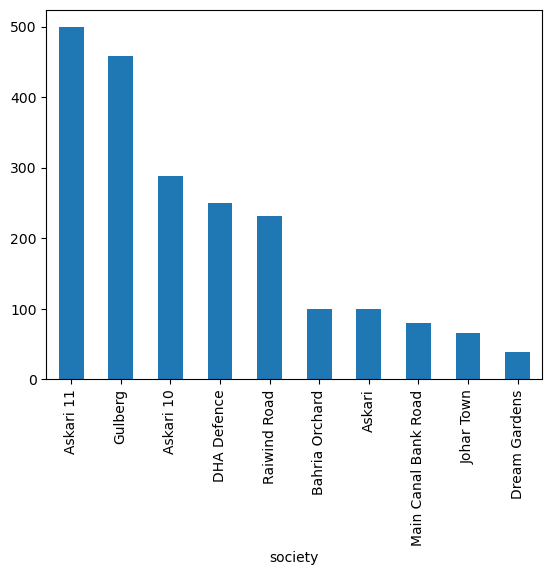

In [25]:
df["society"].value_counts().head(10).plot(kind='bar')

In [26]:
df['society'].isnull().sum()

np.int64(0)

In [24]:
df["society"] = df["society"].replace(r"^Gulberg 3(\s+\d+)?$", "Gulberg", regex=True)

### Observability
- 87 socities/area
- {'Very High (>100)': np.int64(5),
- 'High (50-100)': np.int64(4),
- 'Average (10-49)': np.int64(12),
- 'Low (2-9)': np.int64(38),
- 'Very Low (1)': np.int64(24)}
- no missing val

## Pandas profiling

## Multivarient analysis